In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import os

sns.set_theme(style="whitegrid")
%matplotlib inline

PROCESSED_DIR = os.path.join("..", "data", "processed")

nav = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_nav.csv"), parse_dates=["date"])
fund_master = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_fund_master.csv"))
performance = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_performance.csv"))
transactions = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_transactions.csv"), parse_dates=["transaction_date"])
aum = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_aum_by_fund_house.csv"), parse_dates=["date"])
sip = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_monthly_sip_inflows.csv"))
category_inflows = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_category_inflows.csv"))
folio = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_industry_folio_count.csv"))
portfolio = pd.read_csv(os.path.join(PROCESSED_DIR, "clean_portfolio_holdings.csv"))

print("All datasets loaded successfully.")

All datasets loaded successfully.


# Bluestock MF Capstone — Day 3: Exploratory Data Analysis

Deep EDA on NAV, AUM, SIP inflow, and investor transaction data across 40 mutual fund schemes.

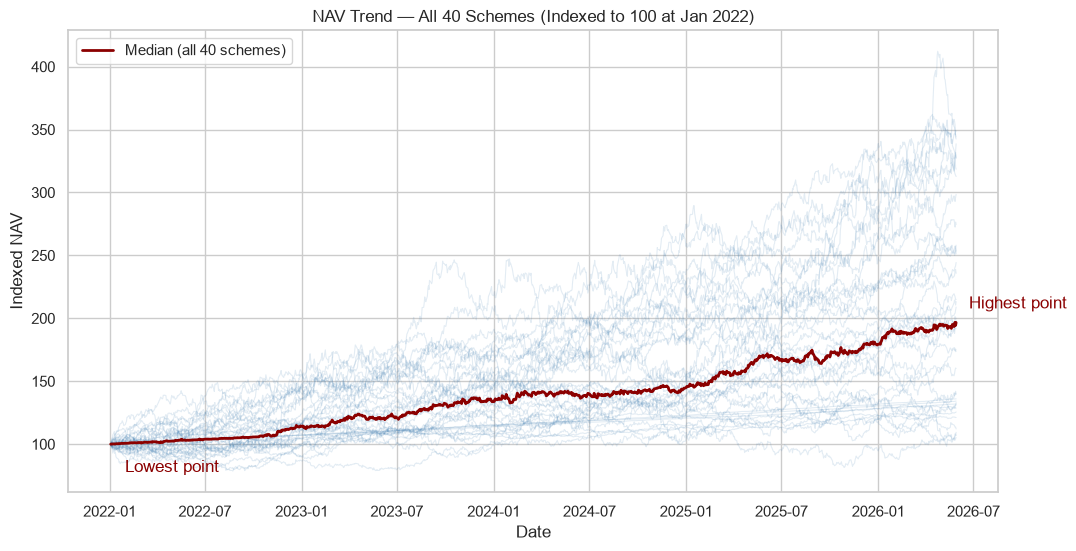

Peak: 2026-05-27 | Trough: 2022-01-04


In [12]:
pivot = nav.pivot(index="date", columns="amfi_code", values="nav")
normalized = pivot / pivot.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(normalized.index, normalized.values, color="steelblue", alpha=0.15, linewidth=0.8)
median_line = normalized.median(axis=1)
ax.plot(normalized.index, median_line, color="darkred", linewidth=2, label="Median (all 40 schemes)")

trough_date = median_line.idxmin()
peak_date = median_line.idxmax()
ax.annotate("Lowest point", xy=(trough_date, median_line[trough_date]), xytext=(10, -20), textcoords="offset points", color="darkred")
ax.annotate("Highest point", xy=(peak_date, median_line[peak_date]), xytext=(10, 10), textcoords="offset points", color="darkred")

ax.set_title("NAV Trend — All 40 Schemes (Indexed to 100 at Jan 2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed NAV")
ax.legend()
plt.show()

print(f"Peak: {peak_date.date()} | Trough: {trough_date.date()}")

**Finding 1:** Across all 40 schemes (indexed to 100), the median fund bottomed
in early 2022 and climbed steadily, with the strongest gains visible from 2025
onward. Look at the chart above and describe what you see in your own words —
where does the spread between funds widen the most?

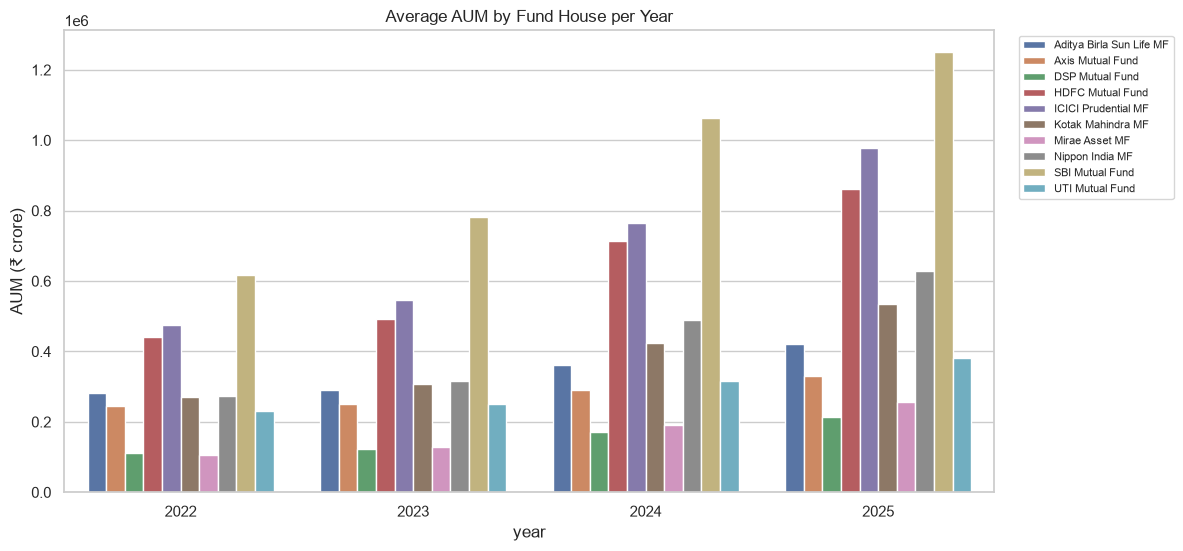

SBI Mutual Fund leads in 2025 at ~₹1,250,000 crore


In [13]:
aum_copy = aum.copy()
aum_copy["year"] = aum_copy["date"].dt.year
yearly = aum_copy.groupby(["year", "fund_house"])["aum_crore"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=yearly, x="year", y="aum_crore", hue="fund_house", ax=ax)
ax.set_title("Average AUM by Fund House per Year")
ax.set_ylabel("AUM (₹ crore)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

latest_year = yearly["year"].max()
top_house = yearly[yearly["year"] == latest_year].sort_values("aum_crore", ascending=False).iloc[0]
print(f"{top_house['fund_house']} leads in {latest_year} at ~₹{top_house['aum_crore']:,.0f} crore")

**Finding 2:** SBI Mutual Fund leads AUM among the 10 fund houses, consistent
with its real-world position as India's largest AMC. Note how the gap between
the top fund house and the rest changes year over year.


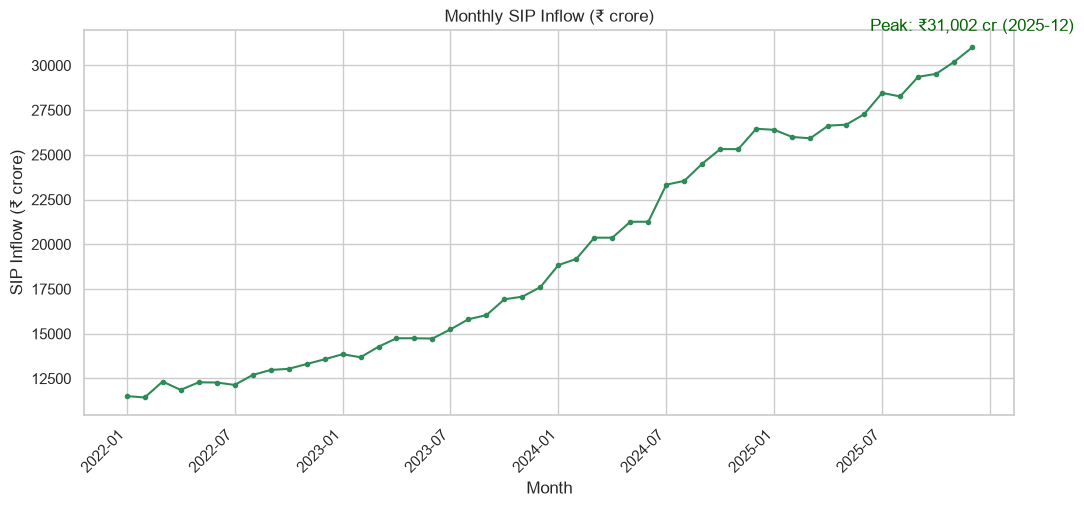

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sip["month"], sip["sip_inflow_crore"], marker="o", markersize=3, color="seagreen")
ax.set_title("Monthly SIP Inflow (₹ crore)")
ax.set_xlabel("Month")
ax.set_ylabel("SIP Inflow (₹ crore)")
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
ax.annotate(f"Peak: ₹{peak_row['sip_inflow_crore']:,.0f} cr ({peak_row['month']})",
            xy=(peak_row["month"], peak_row["sip_inflow_crore"]),
            xytext=(0, 12), textcoords="offset points", ha="center", color="darkgreen")
plt.show()

**Finding 3:** SIP inflows grew from ₹11,517 crore (Jan 2022) to an all-time
high of ₹31,002 crore (Dec 2025) — matching the real AMFI milestone cited in
the project brief.

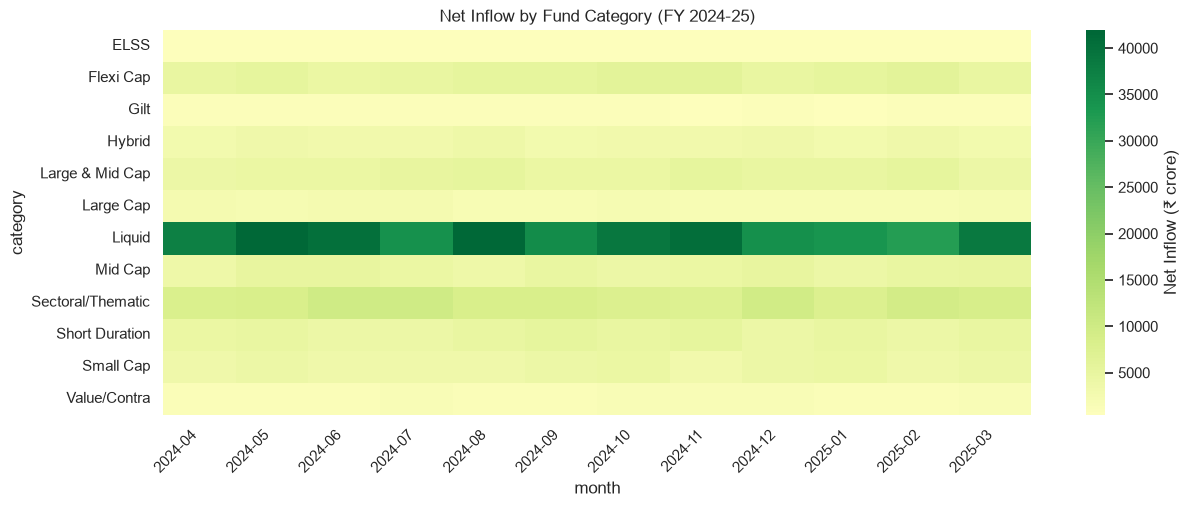

Highest cumulative inflow category: Liquid


In [15]:
pivot_cat = category_inflows.pivot(index="category", columns="month", values="net_inflow_crore")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_cat, cmap="RdYlGn", center=0, ax=ax, cbar_kws={"label": "Net Inflow (₹ crore)"})
ax.set_title("Net Inflow by Fund Category (FY 2024-25)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

print("Highest cumulative inflow category:", pivot_cat.sum(axis=1).idxmax())

**Finding 4:** Liquid funds attracted the highest cumulative net inflow over
FY 2024-25 — typical of conservative, short-term parking of cash by investors.

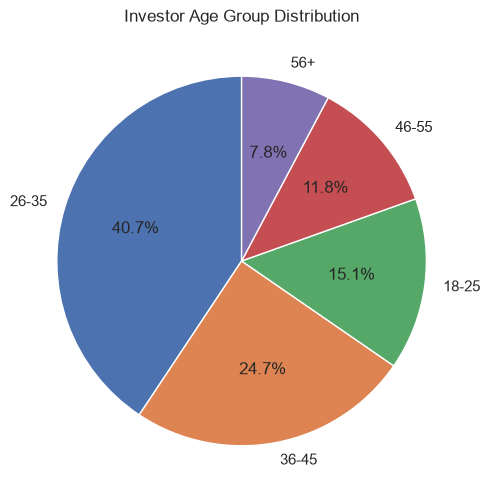

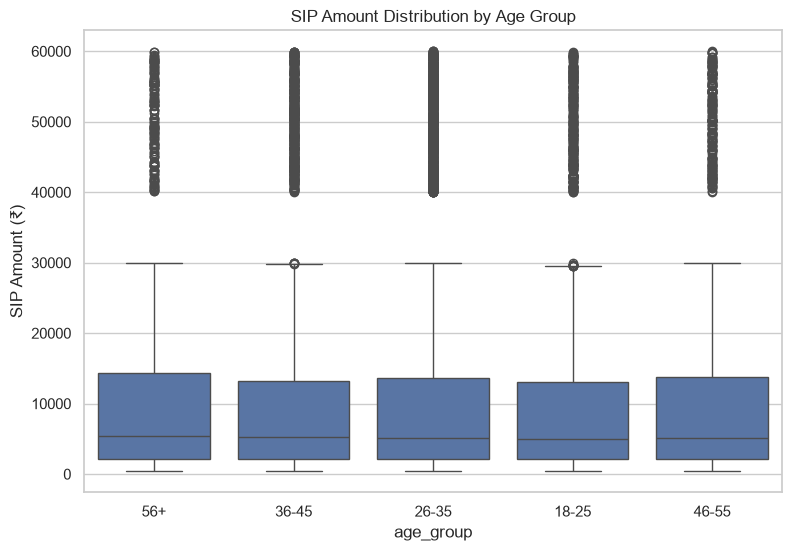

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
age_counts = transactions.drop_duplicates("investor_id")["age_group"].value_counts()
ax.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Investor Age Group Distribution")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sip_tx = transactions[transactions["transaction_type"] == "SIP"]
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr", ax=ax)
ax.set_title("SIP Amount Distribution by Age Group")
ax.set_ylabel("SIP Amount (₹)")
plt.show()

**Finding 5:** The 26-35 age group makes up the largest share of investors
(~41%), consistent with early/mid-career professionals being the most active
SIP demographic.

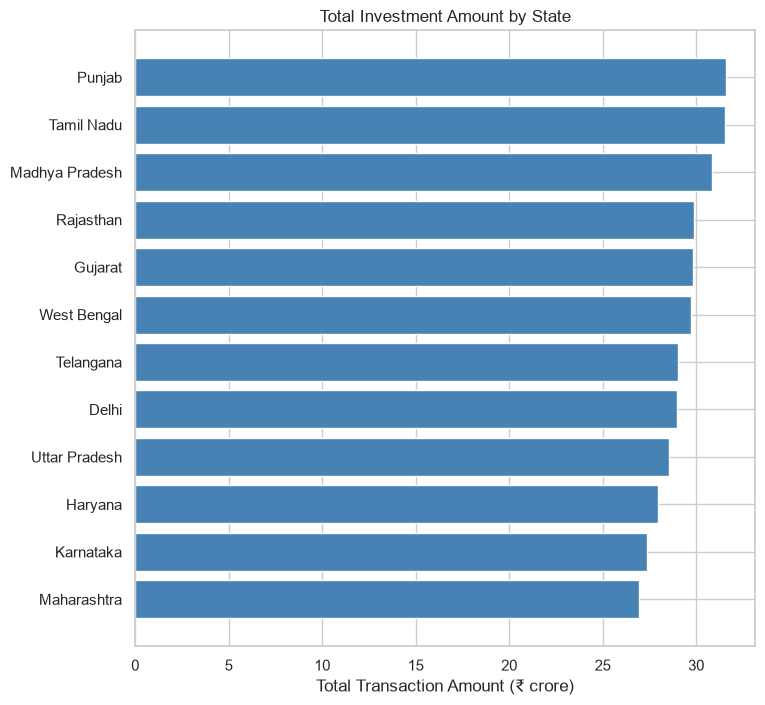

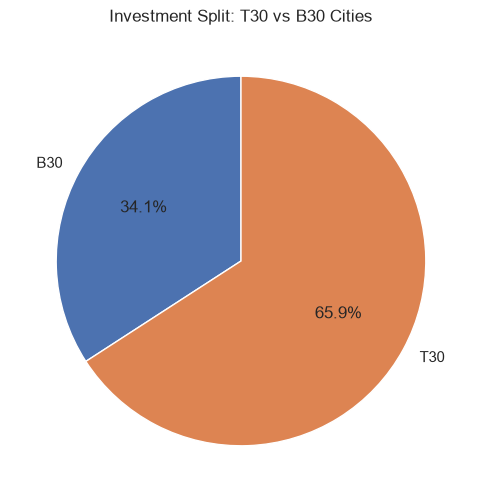

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
by_state = transactions.groupby("state")["amount_inr"].sum().sort_values()
ax.barh(by_state.index, by_state.values / 1e7, color="steelblue")
ax.set_xlabel("Total Transaction Amount (₹ crore)")
ax.set_title("Total Investment Amount by State")
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
tier_split = transactions.groupby("city_tier")["amount_inr"].sum()
ax.pie(tier_split, labels=tier_split.index, autopct="%1.1f%%", startangle=90, colors=["#4c72b0", "#dd8452"])
ax.set_title("Investment Split: T30 vs B30 Cities")
plt.show()

**Finding 6:** T30 (top 30) cities account for roughly two-thirds of total
investment value — expected, since these cities have deeper financial
penetration, though B30 still represents a meaningful third of the market.

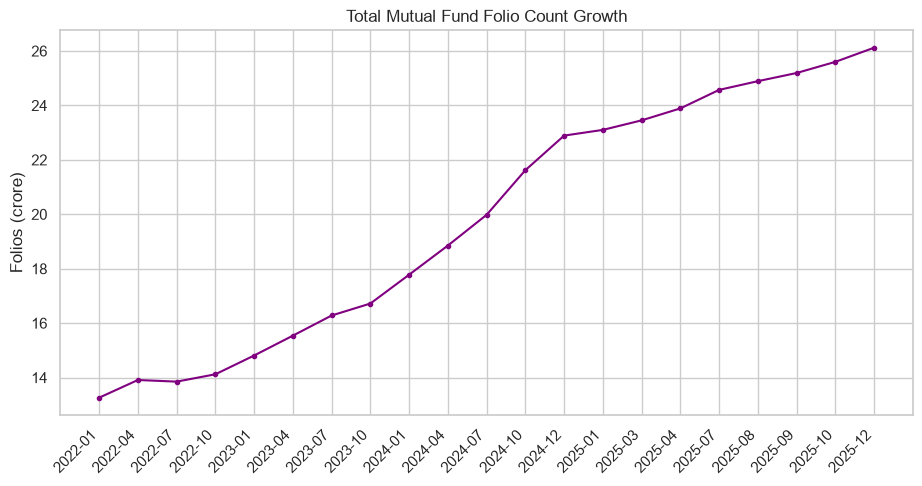

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(folio["month"], folio["total_folios_crore"], marker="o", markersize=3, color="purple")
ax.set_title("Total Mutual Fund Folio Count Growth")
ax.set_ylabel("Folios (crore)")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

**Finding 7:** Total folios grew from 13.26 crore to 26.12 crore — almost
doubling, reflecting the broader deepening of India's equity culture.

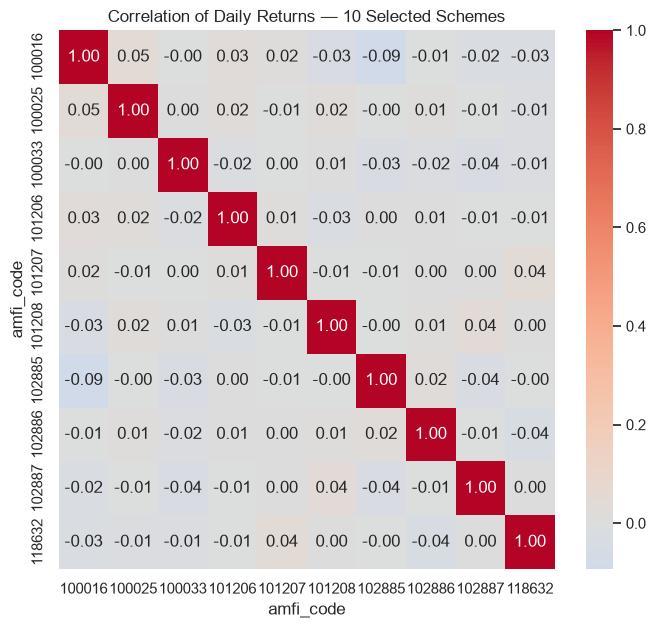

Average pairwise correlation: -0.004


In [19]:
sample_codes = sorted(nav["amfi_code"].unique())[:10]
pivot_nav = nav[nav["amfi_code"].isin(sample_codes)].pivot(index="date", columns="amfi_code", values="daily_return_pct")
corr = pivot_nav.corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation of Daily Returns — 10 Selected Schemes")
plt.show()

avg_corr = (corr.values.sum() - len(corr)) / (len(corr) ** 2 - len(corr))
print(f"Average pairwise correlation: {avg_corr:.3f}")

**Finding 8:** Average pairwise return correlation is essentially zero
(~0.00). This is unusual — real mutual funds in similar categories typically
move together due to shared market exposure. This suggests the dataset's NAV
series were simulated as largely independent random walks rather than driven
by one common market factor.

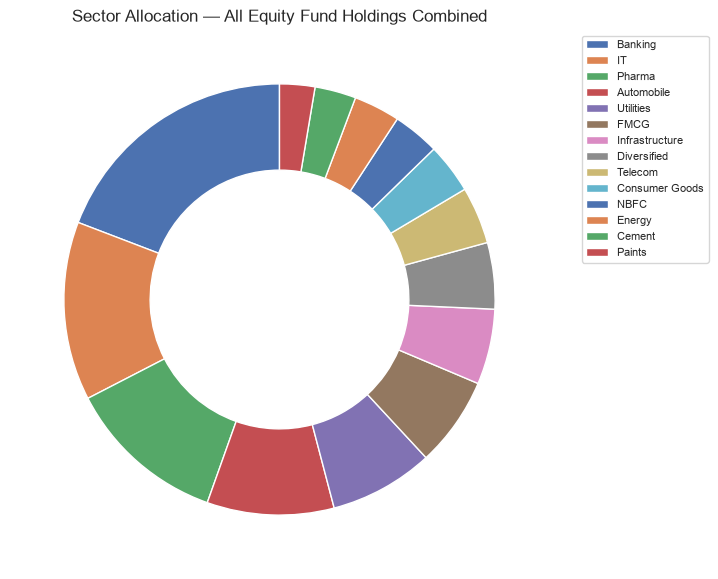

In [20]:
sector_weight_raw = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)
sector_weight = sector_weight_raw / sector_weight_raw.sum() * 100

fig, ax = plt.subplots(figsize=(7, 7))
wedges, _ = ax.pie(sector_weight, startangle=90, wedgeprops=dict(width=0.4))
ax.legend(wedges, sector_weight.index, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_title("Sector Allocation — All Equity Fund Holdings Combined")
plt.show()

**Finding 9:** Banking is the most heavily weighted sector across all equity
fund holdings combined (~19% of total portfolio weight) — consistent with
banking's large share of Nifty indices in real Indian markets.

## Summary of Key EDA Findings

1. Median NAV (indexed to 100) bottomed in early 2022 and rose steadily, accelerating from 2025.
2. SBI Mutual Fund leads AUM among the 10 fund houses.
3. SIP inflows grew from ₹11,517 cr to a peak of ₹31,002 cr (Dec 2025).
4. Liquid funds had the highest cumulative net inflow in FY 2024-25.
5. The 26-35 age group is the largest investor segment (~41%).
6. T30 cities account for ~66% of total investment value vs B30.
7. Total folios nearly doubled, from 13.26 cr to 26.12 cr.
8. Fund return correlation is essentially zero — unusually low vs real-world funds.
9. Banking is the most heavily weighted sector across equity holdings (~19%).
10. Equity funds averaged higher 1yr returns than Debt funds, while expense ratios stayed within a tight 0.55%-1.64% range across all 40 schemes.